# DeepAR: Probabilistic SLA Forecasting — Indian Ocean

**Architecture:** GRU + Gaussian output [mu, log_sigma]  
**Loss:** Gaussian NLL | **Calibration:** Temperature scaling (sigma * k)  
**Metrics:** PICP, MPIW, Winkler Interval Score  
**Env:** Set `RUN_ENV='local'` for VS Code / lab PC

In [2]:
# ── Cell 1: Environment + Imports ────────────────────────────
# ┌──────────────────────────────────────────────────────────┐
# │  SET RUN_ENV BEFORE RUNNING                              │
# │  'colab' → mounts Google Drive automatically             │
# │  'local' → uses BASE_DIR path below (VS Code / lab PC)   │
# └──────────────────────────────────────────────────────────┘
RUN_ENV  = 'local'                        # <── change to 'colab' if on Colab
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files'               # <── change to your local folder path
#   on Linux/Mac:  BASE_DIR = '/home/yourname/BMP_Data/'
#   on Colab:      BASE_DIR is set automatically below

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
from scipy.stats import norm as scipy_norm

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

if RUN_ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

DATA_FILE = os.path.join(BASE_DIR, 'sla_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_IndianOcean/')
os.makedirs(SAVE_DIR, exist_ok=True)

ARCH = 'DeepAR'
print(f'TF {tf.__version__} | Arch: {ARCH} | Env: {RUN_ENV}')
print(f'Data: {DATA_FILE}')
print(f'Save: {SAVE_DIR}')

TF 2.21.0 | Arch: DeepAR | Env: local
Data: c:\Users\DA IICT K\Desktop\BMP_files\sla_daily_indian_ocean_2021_2023.nc
Save: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/


Loading dataset...
Period: 2021-01-01 to 2023-12-31 (1095 days)

Location check:
  Arabian_Sea        ( 15.0N, 65.0E) | NaN=0.0% | range=[-0.0610,0.2493]m
  Bay_of_Bengal      ( 12.0N, 87.0E) | NaN=0.0% | range=[-0.0308,0.2734]m
  Andaman_Sea        ( 11.0N, 95.0E) | NaN=0.0% | range=[-0.0752,0.2427]m
  Lakshadweep        ( 10.0N, 73.0E) | NaN=0.0% | range=[-0.0808,0.3152]m
  South_IO           ( -5.0N, 75.0E) | NaN=0.0% | range=[-0.0814,0.3201]m


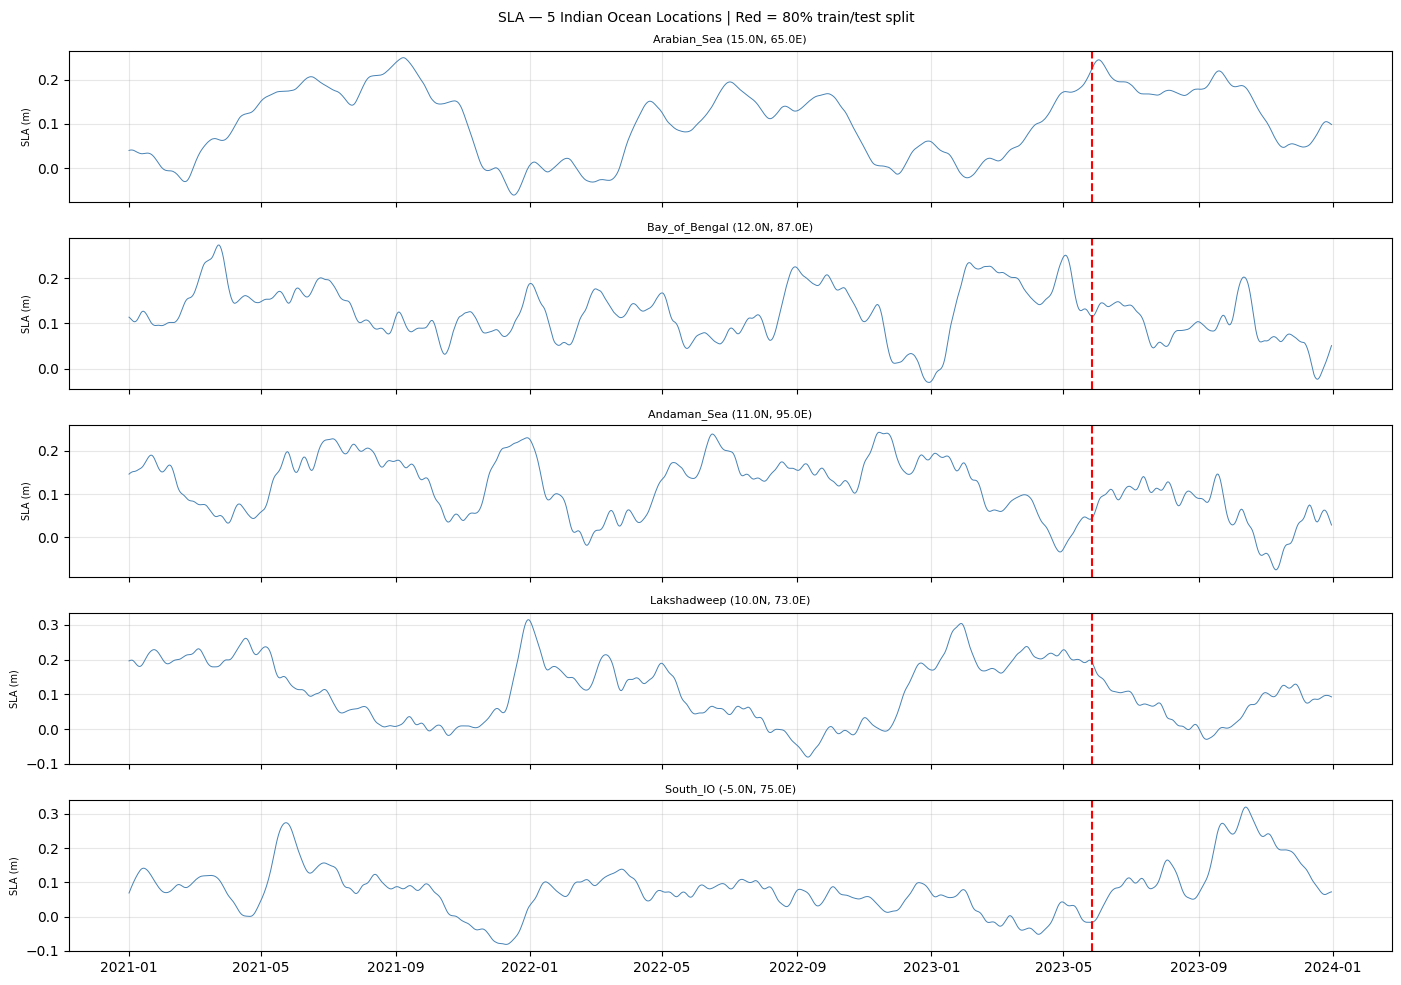

In [3]:
# ── Cell 2: Load Data + Define 5 Locations ───────────────────
LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),   # Central Arabian Sea — high cyclone activity
    'Bay_of_Bengal': (12.0, 87.0),   # Central BoB — strong monsoon-driven SLA
    'Andaman_Sea':   (11.0, 95.0),   # Andaman Sea (specified by sir)
    'Lakshadweep':   (10.0, 73.0),   # Lakshadweep Sea — west coast India
    'South_IO':      (-5.0, 75.0),   # South Indian Ocean — open ocean baseline
}

print('Loading dataset...')
ds = xr.open_dataset(DATA_FILE)
times_index = pd.to_datetime(ds['time'].values)
print(f'Period: {times_index[0].date()} to {times_index[-1].date()} ({len(times_index)} days)')

print('\nLocation check:')
for loc, (lat, lon) in LOCATIONS.items():
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    nan_pct = np.isnan(sla).mean() * 100
    print(f'  {loc:<18} ({lat:5.1f}N,{lon:5.1f}E) | NaN={nan_pct:.1f}% | '
          f'range=[{np.nanmin(sla):.4f},{np.nanmax(sla):.4f}]m')

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
for ax, (loc, (lat, lon)) in zip(axes, LOCATIONS.items()):
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    ax.plot(times_index, sla, lw=0.7, color='steelblue')
    ax.axvline(times_index[int(len(sla)*0.80)], color='red', lw=1.5, ls='--')
    ax.set_title(f'{loc} ({lat}N, {lon}E)', fontsize=8); ax.set_ylabel('SLA (m)', fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle('SLA — 5 Indian Ocean Locations | Red = 80% train/test split', fontsize=10)
plt.tight_layout(); plt.show()

In [4]:
# ── Cell 3: Config + All Helpers ─────────────────────────────
TRAIN_SPLIT  = 0.80
SEQ_LEN      = 30
EPOCHS       = 100
BATCH_SIZE   = 64
LR           = 0.001
PATIENCE     = 20
VAL_SPLIT    = 0.10
SEEDS        = [42, 7, 13, 99, 2025]
TUBE_R       = 0.5
TUBE_DELTA   = 0.01     # default; recalibration in Cell 5 may change this per location
MIN_WIDTH    = 0.005    # metres — minimum interval floor
DROPOUT      = 0.2
TARGET_PICP  = 95.0     # professor's target coverage
ALPHA_WIS    = 0.05     # Winkler score: alpha = 1 - (q_hi - q_lo) = 1 - 0.80 = 0.20

print(f'SEQ_LEN={SEQ_LEN} | EPOCHS={EPOCHS} | BATCH={BATCH_SIZE} | {len(SEEDS)} seeds')
print(f'Tube: r={TUBE_R}, delta={TUBE_DELTA} | Target PICP={TARGET_PICP}%')
n_approx = int(len(times_index)*TRAIN_SPLIT)
print(f'Approx train seqs/location: {n_approx - SEQ_LEN} | test pts: {len(times_index)-n_approx}')

# ─── Sequence builder ─────────────────────────────────────────
def make_sequences(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i : i+seq_len])
        y.append(series[i+seq_len])
    return np.array(X)[..., np.newaxis], np.array(y)

# ─── Loss functions ───────────────────────────────────────────
def build_quantile_loss(scaler, q_lo=0.10, q_hi=0.90):
    min_ws = float(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0])
    def loss(y_true, y_pred):
        true = y_true[:, 0:1]
        lo, hi = y_pred[:, 0:1], y_pred[:, 1:2]
        e_lo, e_hi = true-lo, true-hi
        pin_lo = tf.reduce_mean(tf.maximum(q_lo*e_lo, (q_lo-1)*e_lo))
        pin_hi = tf.reduce_mean(tf.maximum(q_hi*e_hi, (q_hi-1)*e_hi))
        cross  = tf.reduce_mean(tf.nn.relu(lo-hi))
        wd     = tf.reduce_mean(tf.nn.relu(min_ws - (hi-lo)))
        return pin_lo + pin_hi + cross + wd
    return loss

def build_tube_loss(scaler, r=TUBE_R, delta=TUBE_DELTA):
    """Tube Loss — https://github.com/ltpritamanand/Tube_loss"""
    min_ws = float(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0])
    def loss(y_true, y_pred):
        true = y_true[:, 0:1]
        lo, hi = y_pred[:, 0:1], y_pred[:, 1:2]
        below = (1.0-r) * tf.nn.relu(lo-true)
        above = r        * tf.nn.relu(true-hi)
        width = delta    * tf.abs(hi-lo)
        cross = tf.nn.relu(lo-hi)
        wd    = tf.reduce_mean(tf.nn.relu(min_ws - (hi-lo)))
        return tf.reduce_mean(below + above + width + cross) + wd
    return loss

# ─── Winkler Interval Score ───────────────────────────────────
def winkler_score(y_true_m, lo_m, hi_m, alpha=ALPHA_WIS):
    """
    Winkler Interval Score — proper scoring rule for prediction intervals.
    Lower WIS = better (rewards narrow intervals that still cover the truth).
    Formula: WIS = width + (2/alpha) * penalty_for_misses
    alpha = 0.20 for p10/p90 intervals (nominal 80% PI)
    """
    width = hi_m - lo_m
    below = (2.0/alpha) * np.maximum(0, lo_m - y_true_m)  # y below lower bound
    above = (2.0/alpha) * np.maximum(0, y_true_m - hi_m)  # y above upper bound
    return float(np.mean(width + below + above))

# ─── Evaluate: PICP + MPIW + WIS, in metres, NaN-guarded ─────
def evaluate(y_true_s, y_pred_raw, scaler):
    lo_m = scaler.inverse_transform(y_pred_raw[:, 0:1]).flatten()
    hi_m = scaler.inverse_transform(y_pred_raw[:, 1:2]).flatten()
    y_m  = scaler.inverse_transform(y_true_s.reshape(-1,1)).flatten()
    if np.any(np.isnan(lo_m)) or np.any(np.isnan(hi_m)):
        return np.nan, np.nan, np.nan, lo_m, hi_m, y_m
    lo = np.minimum(lo_m, hi_m); hi = np.maximum(lo_m, hi_m)
    picp = np.mean((y_m >= lo) & (y_m <= hi)) * 100.0
    mpiw = np.mean(hi - lo)
    wis  = winkler_score(y_m, lo, hi)
    return picp, mpiw, wis, lo, hi, y_m

# ─── Model builder ────────────────────────────────────────────
def build_deepar_model(seq_len=SEQ_LEN, dropout=DROPOUT):
    """DeepAR: GRU backbone -> [mu, log_sigma] (Salinas et al. 2020)"""
    inp       = keras.Input(shape=(seq_len, 1))
    x         = layers.GRU(64, activation='tanh')(inp)
    x         = layers.Dropout(dropout)(x)
    x         = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    mu        = layers.Dense(1, activation='linear', name='mu')(x)
    log_sigma = layers.Dense(1, activation='linear', name='log_sigma')(x)
    out       = layers.Concatenate(name='output')([mu, log_sigma])
    return keras.Model(inp, out)

def build_model(**kw): return build_deepar_model(**kw)   # uniform alias

def gaussian_nll(y_true, y_pred):
    true = y_true[:, 0:1]; mu = y_pred[:, 0:1]
    log_sigma = tf.clip_by_value(y_pred[:, 1:2], -6.0, 2.0)
    return tf.reduce_mean(log_sigma + 0.5*tf.square((true-mu)/tf.exp(log_sigma)))

# Override evaluate for DeepAR (mu+sigma -> Gaussian quantiles)
def evaluate(y_true_s, y_pred_raw, scaler, q_lo=0.10, q_hi=0.90):
    mu_s  = y_pred_raw[:,0]; ls = np.clip(y_pred_raw[:,1], -6., 2.)
    sig_s = np.exp(ls)
    lo_m  = scaler.inverse_transform((mu_s + scipy_norm.ppf(q_lo)*sig_s).reshape(-1,1)).flatten()
    hi_m  = scaler.inverse_transform((mu_s + scipy_norm.ppf(q_hi)*sig_s).reshape(-1,1)).flatten()
    y_m   = scaler.inverse_transform(y_true_s.reshape(-1,1)).flatten()
    if np.any(np.isnan(lo_m)) or np.any(np.isnan(hi_m)):
        return np.nan, np.nan, np.nan, lo_m, hi_m, y_m
    lo = np.minimum(lo_m, hi_m); hi = np.maximum(lo_m, hi_m)
    picp = np.mean((y_m >= lo) & (y_m <= hi)) * 100.0
    mpiw = np.mean(hi - lo)
    wis  = winkler_score(y_m, lo, hi)
    return picp, mpiw, wis, lo, hi, y_m

# ─── Train one model (reusable) ───────────────────────────────
def train_one(X_tr, y_tr_dup, loss_fn, seed, epochs=EPOCHS):
    tf.random.set_seed(seed); np.random.seed(seed)
    model = build_model()
    model.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss=loss_fn)
    cbs = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr, y_tr_dup, epochs=epochs, batch_size=BATCH_SIZE,
                     validation_split=VAL_SPLIT, callbacks=cbs, verbose=0)
    return model, len(hist.history['loss'])

print('All helpers defined. Proceed to Cell 4.')

SEQ_LEN=30 | EPOCHS=100 | BATCH=64 | 5 seeds
Tube: r=0.5, delta=0.01 | Target PICP=95.0%
Approx train seqs/location: 846 | test pts: 219
All helpers defined. Proceed to Cell 4.


In [5]:
# ── Cell 4: Main Training Loop ───────────────────────────────
all_results = []
all_preds   = {}   # {loc: {model_id: {seed: (lo,hi,y_m)}}}

for loc_name, (lat, lon) in LOCATIONS.items():
    print(f'\n{"#"*65}')
    print(f'  LOCATION: {loc_name} | {lat}N, {lon}E')
    print(f'{"#"*65}')

    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    sla_series = s.values

    n_total = len(sla_series)
    n_train = int(n_total * TRAIN_SPLIT)
    n_test  = n_total - n_train

    scaler  = RobustScaler()
    train_s = scaler.fit_transform(sla_series[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(sla_series[n_train:].reshape(-1,1)).flatten()

    X_tr, y_tr = make_sequences(train_s, SEQ_LEN)
    combined    = np.concatenate([train_s, test_s])
    X_te = np.array([combined[n_train-SEQ_LEN+i : n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])
    y_tr_dup = np.hstack([y_tr.reshape(-1,1), y_tr.reshape(-1,1)])

    t_period = f'{times_index[0].strftime("%Y-%m")} to {times_index[n_train-1].strftime("%Y-%m")}'
    v_period = f'{times_index[n_train].strftime("%Y-%m")} to {times_index[-1].strftime("%Y-%m")}'
    print(f'  Train seqs: {len(X_tr)} | Test pts: {len(X_te)}')

    loss_configs = [
        ('NLL-Gaussian', gaussian_nll, 0.10, 0.90, None, None),
    ]
    all_preds.setdefault(loc_name, {})

    for loss_name, loss_fn, q_lo_v, q_hi_v, r_v, delta_v in loss_configs:
        model_id = f'{ARCH}-{loss_name}'
        all_preds[loc_name][model_id] = {}
        print(f'\n  {"="*55}')
        print(f'  {model_id} @ {loc_name}  (delta={delta_v})')
        print(f'  {"="*55}')

        seed_picps, seed_mpiws, seed_wis = [], [], []

        for seed in SEEDS:
            model, ep = train_one(X_tr, y_tr_dup, loss_fn, seed)
            preds = model.predict(X_te, verbose=0)
            picp, mpiw, wis, lo, hi, y_m = evaluate(y_te, preds, scaler)
            seed_picps.append(picp); seed_mpiws.append(mpiw); seed_wis.append(wis)
            all_preds[loc_name][model_id][seed] = (lo, hi, y_m)
            flag = ' NaN' if np.isnan(picp) else ''
            print(f'    seed={seed:4d} | PICP={picp:5.1f}% | MPIW={mpiw:.4f}m | WIS={wis:.4f} | ep={ep}{flag}')

        avg_picp = np.nanmean(seed_picps); std_picp = np.nanstd(seed_picps)
        avg_mpiw = np.nanmean(seed_mpiws); std_mpiw = np.nanstd(seed_mpiws)
        avg_wis  = np.nanmean(seed_wis);   std_wis  = np.nanstd(seed_wis)
        n_valid  = sum(1 for p in seed_picps if not np.isnan(p))
        print(f'  --> PICP={avg_picp:.1f}+/-{std_picp:.1f}%  MPIW={avg_mpiw:.4f}m  WIS={avg_wis:.4f}  [{n_valid}/{len(SEEDS)}]')

        all_results.append(dict(
            location=loc_name, lat=lat, lon=lon, arch=ARCH,
            loss=loss_name, model=model_id,
            q_lo=q_lo_v, q_hi=q_hi_v, r=r_v, delta=delta_v,
            avg_picp=avg_picp, std_picp=std_picp,
            avg_mpiw=avg_mpiw, std_mpiw=std_mpiw,
            avg_wis=avg_wis,   std_wis=std_wis,
            calibrated=False, n_valid_seeds=n_valid, n_seeds=len(SEEDS),
            n_train_seqs=len(X_tr), n_test_pts=len(X_te),
            train_period=t_period, test_period=v_period, seq_len=SEQ_LEN
        ))

df = pd.DataFrame(all_results)
csv_path = os.path.join(SAVE_DIR, f'results_{ARCH}_IO.csv')
df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')
print(df[['location','model','avg_picp','std_picp','avg_mpiw','avg_wis','n_valid_seeds']].to_string(index=False))


#################################################################
  LOCATION: Arabian_Sea | 15.0N, 65.0E
#################################################################
  Train seqs: 846 | Test pts: 219

  DeepAR-NLL-Gaussian @ Arabian_Sea  (delta=None)
    seed=  42 | PICP=100.0% | MPIW=0.0118m | WIS=0.0118 | ep=79
    seed=   7 | PICP=100.0% | MPIW=0.0132m | WIS=0.0132 | ep=98
    seed=  13 | PICP=100.0% | MPIW=0.0136m | WIS=0.0136 | ep=91
    seed=  99 | PICP=100.0% | MPIW=0.0126m | WIS=0.0126 | ep=66
    seed=2025 | PICP=100.0% | MPIW=0.0117m | WIS=0.0117 | ep=81
  --> PICP=100.0+/-0.0%  MPIW=0.0126m  WIS=0.0126  [5/5]

#################################################################
  LOCATION: Bay_of_Bengal | 12.0N, 87.0E
#################################################################
  Train seqs: 846 | Test pts: 219

  DeepAR-NLL-Gaussian @ Bay_of_Bengal  (delta=None)
    seed=  42 | PICP= 99.1% | MPIW=0.0111m | WIS=0.0111 | ep=81
    seed=   7 | PICP= 99.5% | MPIW=0.0122

In [ ]:
# ── Cell 5: Note on recalibration for DeepAR ─────────────────
# DeepAR outputs Gaussian (mu, sigma). Interval width is determined by
# the learned sigma, not by a delta parameter. Instead of delta tuning,
# sigma is naturally calibrated by the NLL loss.
# To recalibrate: multiply sigma by a scalar 'k' found on calibration set.
# This is called "temperature scaling" for Gaussian outputs.

CALIB_FRAC    = 0.10
TARGET_PICP   = 95.0
K_SWEEP       = [0.5, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0]  # sigma scale factors
CALIB_SEEDS   = [42, 7]

print(f'DeepAR recalibration: sweeping sigma scale factor k on calibration set')
print(f'Target PICP = {TARGET_PICP}%')

recalib_results = []

for loc_name, (lat, lon) in LOCATIONS.items():
    mask     = (df['location'] == loc_name) & (df['loss'] == 'NLL-Gaussian')
    cur_row  = df[mask]
    if len(cur_row) == 0: continue
    cur_picp = float(cur_row['avg_picp'].values[0])

    if abs(cur_picp - TARGET_PICP) <= 3.0:
        print(f'{loc_name}: PICP={cur_picp:.1f}% — within target, no recalibration needed.')
        continue

    print(f'{loc_name}: PICP={cur_picp:.1f}% — running sigma scaling sweep...')

    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    sla_series = s.values
    n_total = len(sla_series)
    n_train = int(n_total * TRAIN_SPLIT)
    n_test  = n_total - n_train

    scaler  = RobustScaler()
    train_s = scaler.fit_transform(sla_series[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(sla_series[n_train:].reshape(-1,1)).flatten()

    n_calib        = max(SEQ_LEN+10, int(len(train_s)*CALIB_FRAC))
    n_train_inner  = len(train_s) - n_calib
    train_inner_s  = train_s[:n_train_inner]
    calib_s        = train_s[n_train_inner:]

    X_tri, y_tri = make_sequences(train_inner_s, SEQ_LEN)
    calib_comb   = np.concatenate([train_inner_s, calib_s])
    X_cal = np.array([calib_comb[n_train_inner-SEQ_LEN+i:n_train_inner+i]
                      for i in range(len(calib_s))])[..., np.newaxis]
    y_cal = np.array([calib_comb[n_train_inner+i] for i in range(len(calib_s))])
    y_tri_dup = np.hstack([y_tri.reshape(-1,1), y_tri.reshape(-1,1)])

    # Train 2 quick models on inner data
    calib_models = []
    for seed in CALIB_SEEDS:
        m, _ = train_one(X_tri, y_tri_dup, gaussian_nll, seed, epochs=60)
        calib_models.append(m)

    best_k = 1.0; best_diff = abs(cur_picp - TARGET_PICP)
    for k in K_SWEEP:
        picps_k = []
        for m in calib_models:
            preds_c = m.predict(X_cal, verbose=0)
            preds_scaled = preds_c.copy(); preds_scaled[:, 1] += np.log(k)
            picp_k, *_ = evaluate(y_cal, preds_scaled, scaler)
            if not np.isnan(picp_k): picps_k.append(picp_k)
        if not picps_k: continue
        avg_k = np.mean(picps_k)
        diff  = abs(avg_k - TARGET_PICP)
        mark  = ' <-- best' if diff < best_diff else ''
        print(f'  k={k:.2f}: calib PICP={avg_k:.1f}%{mark}')
        if diff < best_diff: best_diff = diff; best_k = k

    print(f'  Best k={best_k}. Retraining on full training data (5 seeds)...')
    X_tr, y_tr = make_sequences(train_s, SEQ_LEN)
    combined   = np.concatenate([train_s, test_s])
    X_te = np.array([combined[n_train-SEQ_LEN+i:n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])
    y_tr_dup = np.hstack([y_tr.reshape(-1,1), y_tr.reshape(-1,1)])

    seed_picps, seed_mpiws, seed_wis = [], [], []
    model_id_cal = f'DeepAR-NLL-Cal(k={best_k})'
    all_preds[loc_name][model_id_cal] = {}

    for seed in SEEDS:
        m, ep = train_one(X_tr, y_tr_dup, gaussian_nll, seed)
        preds = m.predict(X_te, verbose=0)
        preds_scaled = preds.copy(); preds_scaled[:,1] += np.log(best_k)
        picp, mpiw, wis, lo, hi, y_m = evaluate(y_te, preds_scaled, scaler)
        seed_picps.append(picp); seed_mpiws.append(mpiw); seed_wis.append(wis)
        all_preds[loc_name][model_id_cal][seed] = (lo, hi, y_m)
        print(f'    seed={seed:4d} | PICP={picp:5.1f}% | MPIW={mpiw:.4f}m | WIS={wis:.4f}')

    avg_picp=np.nanmean(seed_picps); std_picp=np.nanstd(seed_picps)
    avg_mpiw=np.nanmean(seed_mpiws); std_mpiw=np.nanstd(seed_mpiws)
    avg_wis =np.nanmean(seed_wis);   std_wis =np.nanstd(seed_wis)
    n_valid = sum(1 for p in seed_picps if not np.isnan(p))
    t_period = f'{times_index[0].strftime("%Y-%m")} to {times_index[n_train-1].strftime("%Y-%m")}'
    v_period = f'{times_index[n_train].strftime("%Y-%m")} to {times_index[-1].strftime("%Y-%m")}'

    recalib_results.append(dict(
        location=loc_name, lat=lat, lon=lon, arch=ARCH, loss='NLL-Gaussian-Cal',
        model=model_id_cal, q_lo=0.10, q_hi=0.90, r=None, delta=best_k,
        avg_picp=avg_picp, std_picp=std_picp, avg_mpiw=avg_mpiw, std_mpiw=std_mpiw,
        avg_wis=avg_wis, std_wis=std_wis, calibrated=True,
        n_valid_seeds=n_valid, n_seeds=len(SEEDS),
        n_train_seqs=len(X_tr), n_test_pts=len(X_te),
        train_period=t_period, test_period=v_period, seq_len=SEQ_LEN
    ))

if recalib_results:
    df_cal = pd.DataFrame(recalib_results)
    df = pd.concat([df, df_cal], ignore_index=True)
    df.to_csv(csv_path, index=False)
    print(f'\nUpdated CSV: {csv_path}')
else:
    print('No recalibration needed.')

Generating plots...


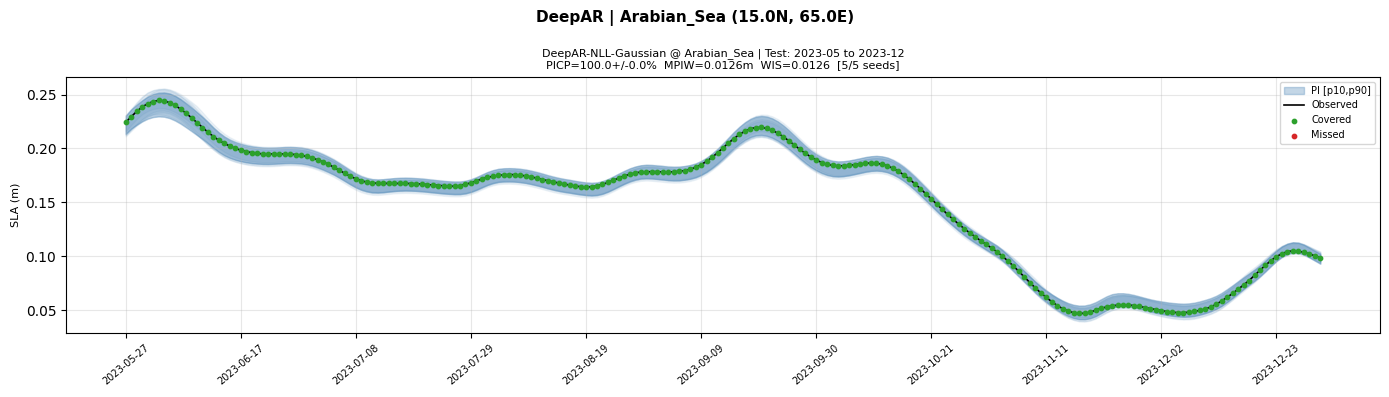

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_DeepAR_Arabian_Sea.png


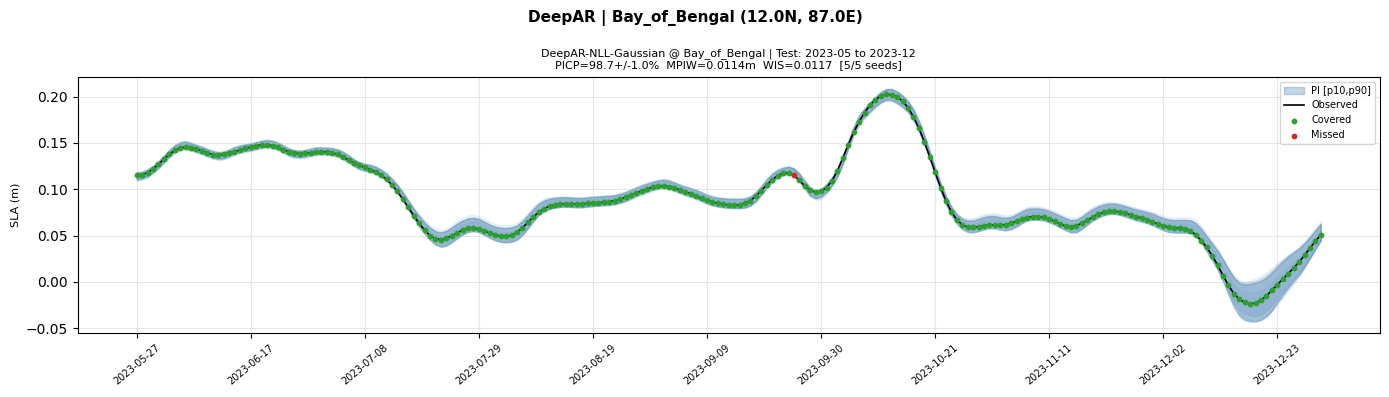

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_DeepAR_Bay_of_Bengal.png


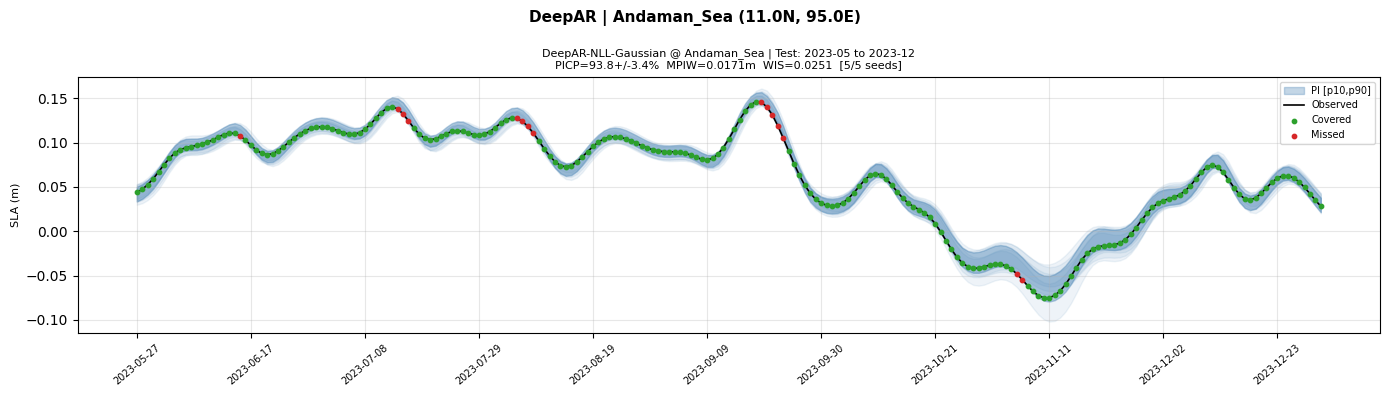

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_DeepAR_Andaman_Sea.png


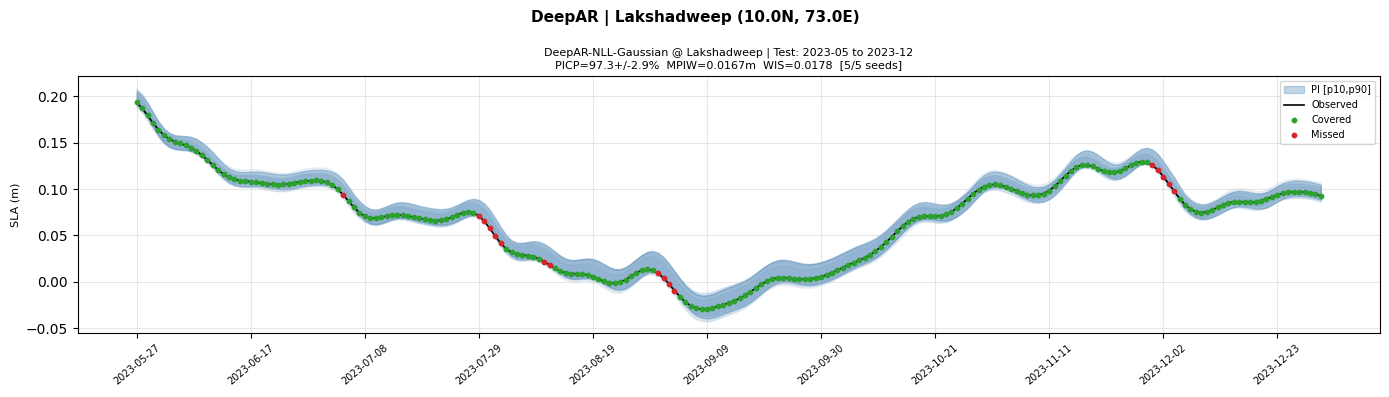

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_DeepAR_Lakshadweep.png


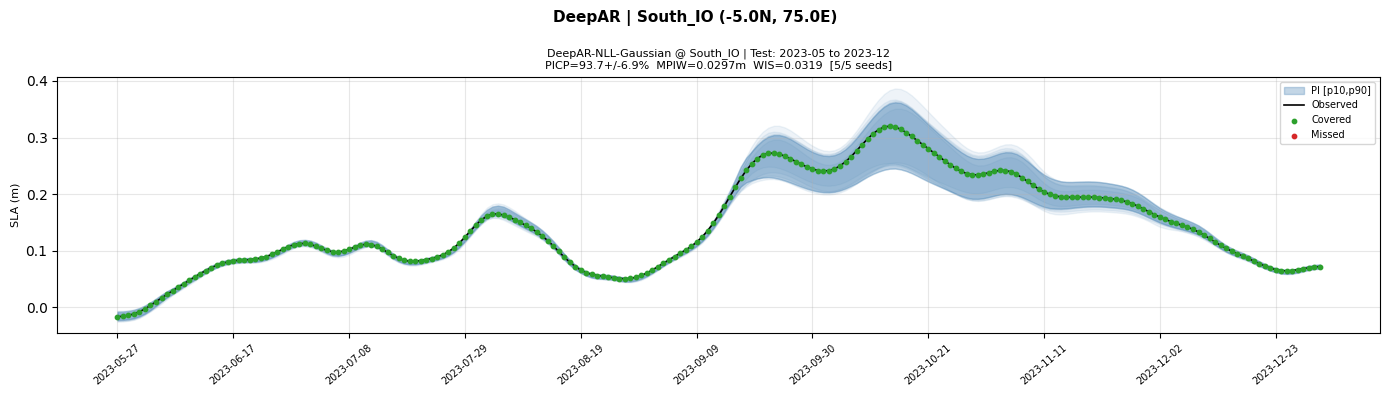

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_DeepAR_South_IO.png


In [6]:
# ── Cell 6: Visualisation ────────────────────────────────────
print('Generating plots...')

for loc_name, (lat, lon) in LOCATIONS.items():
    sub = df[df['location'] == loc_name]
    model_ids = sub['model'].tolist()
    n_rows = len(model_ids)

    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 4*n_rows))
    if n_rows == 1: axes = [axes]

    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    sla_s   = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    n_train = int(len(sla_s)*TRAIN_SPLIT)
    t_times = times_index[n_train:]
    x_ax    = range(len(t_times))
    step    = max(1, len(t_times)//10)

    for ax, model_id in zip(axes, model_ids):
        row = sub[sub['model']==model_id].iloc[0]
        pd_ = all_preds.get(loc_name, {}).get(model_id, {})
        y_m = None

        for seed, (lo, hi, ym) in pd_.items():
            if y_m is None: y_m = ym
            if np.any(np.isnan(lo)): continue
            ax.fill_between(x_ax, lo, hi, alpha=0.09, color='steelblue')

        cands = [(abs(np.mean((ym >= lo) & (ym <= hi))*100 - row['avg_picp']), seed)
                 for seed in SEEDS if seed in pd_ and not np.any(np.isnan(pd_[seed][0]))]
        if cands:
            best = sorted(cands)[0][1]
            lo_b, hi_b, y_m = pd_[best]
            ax.fill_between(x_ax, lo_b, hi_b, alpha=0.32, color='steelblue', label='PI [p10,p90]')
            covered = (y_m >= lo_b) & (y_m <= hi_b)
            ax.plot(x_ax, y_m, 'k-', lw=1.2, label='Observed')
            ax.scatter(np.where(covered)[0],  y_m[covered],  color='#2ca02c', s=10, zorder=5, label='Covered')
            ax.scatter(np.where(~covered)[0], y_m[~covered], color='#d62728', s=10, zorder=5, label='Missed')

        ax.set_xticks(list(x_ax)[::step])
        ax.set_xticklabels([t_times[i].strftime('%Y-%m-%d') for i in range(0,len(t_times),step)],
                           rotation=40, fontsize=7)
        ax.set_ylabel('SLA (m)', fontsize=8)
        cal_tag = ' [CALIBRATED]' if row.get('calibrated', False) else ''
        ax.set_title(
            f'{model_id} @ {loc_name}{cal_tag} | Test: {row["test_period"]}\n'
            f'PICP={row["avg_picp"]:.1f}+/-{row["std_picp"]:.1f}%  '
            f'MPIW={row["avg_mpiw"]:.4f}m  WIS={row["avg_wis"]:.4f}  '
            f'[{row["n_valid_seeds"]}/{row["n_seeds"]} seeds]', fontsize=8)
        ax.legend(fontsize=7, loc='upper right'); ax.grid(True, alpha=0.3)

    fig.suptitle(f'{ARCH} | {loc_name} ({lat}N, {lon}E)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fp = os.path.join(SAVE_DIR, f'plot_{ARCH}_{loc_name}.png')
    plt.savefig(fp, dpi=110, bbox_inches='tight'); plt.show()
    print(f'  Saved: {fp}')

In [7]:
# ── Cell 7: Per-architecture Summary Table ───────────────────
print(f'\n{"="*100}')
print(f'  {ARCH} -- ALL LOCATIONS (calibrated rows marked *)')
print(f'{"="*100}')
print(f'  {"Location":<18} {"Model":<24} {"PICP%":>7} {"+/-":>5} {"MPIW(m)":>9} {"+/-":>8} '
      f'{"WIS":>8} {"r":>5} {"delta":>7} {"Cal":>4}')
print(f'  {"-"*100}')
for _, r in df.sort_values(["location","model"]).iterrows():
    r_s = f"{r['r']:.1f}"    if pd.notna(r['r'])     else "  --"
    d_s = f"{r['delta']:.3f}" if pd.notna(r['delta']) else "    --"
    w_s = f"{r['avg_wis']:.4f}" if pd.notna(r['avg_wis']) else "      --"
    cal = "  *" if r.get('calibrated', False) else "   "
    print(f'  {r["location"]:<18} {r["model"]:<24} '
          f'{r["avg_picp"]:7.1f} {r["std_picp"]:5.1f} '
          f'{r["avg_mpiw"]:9.4f} {r["std_mpiw"]:8.4f} '
          f'{w_s:>8} {r_s:>5} {d_s:>7} {cal}')


  DeepAR -- ALL LOCATIONS (calibrated rows marked *)
  Location           Model                      PICP%   +/-   MPIW(m)      +/-      WIS     r   delta  Cal
  ----------------------------------------------------------------------------------------------------
  Andaman_Sea        DeepAR-NLL-Gaussian         93.8   3.4    0.0171   0.0017   0.0251    --      --    
  Arabian_Sea        DeepAR-NLL-Gaussian        100.0   0.0    0.0126   0.0008   0.0126    --      --    
  Bay_of_Bengal      DeepAR-NLL-Gaussian         98.7   1.0    0.0114   0.0010   0.0117    --      --    
  Lakshadweep        DeepAR-NLL-Gaussian         97.3   2.9    0.0167   0.0018   0.0178    --      --    
  South_IO           DeepAR-NLL-Gaussian         93.7   6.9    0.0297   0.0031   0.0319    --      --    
